In [6]:
# Cell 1: Complete Hybrid PPT Generator with Pexels + Gemini + Local Graphics
import os
import json
import requests
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN
from pptx.dml.color import RGBColor
from PIL import Image, ImageDraw, ImageFont
import google.generativeai as genai
import random
import math
import hashlib
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

class HybridPPTGenerator:
    """
    Hybrid PPT Generator - Uses Pexels for real photos, falls back to graphics
    Uses Gemini when available, falls back to templates
    """
    
    def __init__(self, gemini_api_key=None, pexels_api_key=None):
        """Initialize hybrid generator"""
        print("🔄 Initializing Hybrid PPT Generator...")
        
        # Store API keys
        self.gemini_api_key = gemini_api_key or os.getenv('GEMINI_API_KEY')
        self.pexels_api_key = pexels_api_key or os.getenv('PEXELS_API_KEY')
        
        # Track if we can use APIs
        self.can_use_gemini = False
        self.can_use_pexels = False
        
        # Try to initialize Gemini
        if self.gemini_api_key:
            try:
                genai.configure(api_key=self.gemini_api_key)
                self.model = genai.GenerativeModel('models/gemini-2.0-flash')
                self.can_use_gemini = True
                print("✅ Gemini API: Available")
            except Exception as e:
                print(f"⚠️ Gemini API: Not available ({e})")
                self.can_use_gemini = False
        else:
            print("⚠️ Gemini API: No API key")
        
        # Test Pexels API
        if self.pexels_api_key:
            try:
                # Quick test
                headers = {'Authorization': self.pexels_api_key}
                response = requests.get(
                    'https://api.pexels.com/v1/curated?per_page=1',
                    headers=headers,
                    timeout=5
                )
                if response.status_code == 200:
                    self.can_use_pexels = True
                    print("✅ Pexels API: Available")
                elif response.status_code == 401:
                    print("⚠️ Pexels API: Invalid key")
                elif response.status_code == 429:
                    print("⚠️ Pexels API: Rate limited")
                else:
                    print(f"⚠️ Pexels API: Error {response.status_code}")
            except Exception as e:
                print(f"⚠️ Pexels API: Connection failed ({e})")
        else:
            print("⚠️ Pexels API: No API key")
        
        # Initialize presentation
        self.presentation = Presentation()
        self.presentation.slide_width = Inches(13.33)
        self.presentation.slide_height = Inches(7.5)
        
        # Create directories
        self.temp_dir = "presentation_images"
        self.pexels_cache_dir = os.path.join(self.temp_dir, "pexels_cache")
        self.graphics_cache_dir = os.path.join(self.temp_dir, "graphics_cache")
        
        for dir_path in [self.temp_dir, self.pexels_cache_dir, self.graphics_cache_dir]:
            os.makedirs(dir_path, exist_ok=True)
        
        print("\n" + "="*50)
        print("🎉 Hybrid PPT Generator Ready!")
        print(f"   Gemini: {'✓' if self.can_use_gemini else '✗'}")
        print(f"   Pexels: {'✓' if self.can_use_pexels else '✗'}")
        print(f"   Local Graphics: ✓ (always available)")
        print("="*50 + "\n")
    
    def generate_slide_content(self, topic):
        """Generate slide content - tries Gemini, falls back to templates"""
        
        # If Gemini is available, use it
        if self.can_use_gemini:
            try:
                print(f"🤖 Using Gemini to generate content for: {topic}")
                
                prompt = f"""Create a presentation about "{topic}" with 6-8 slides.
                
                Return ONLY JSON with this exact format:
                {{
                  "title": "Presentation Title",
                  "subtitle": "Brief subtitle",
                  "theme": "tech|health|business|education|environment",
                  "slides": [
                    {{
                      "index": 1,
                      "title": "Slide Title",
                      "type": "cover|agenda|content|conclusion",
                      "key_bullets": ["Bullet 1", "Bullet 2"],
                      "image_prompt": "simple photo keyword (1-2 words)"
                    }}
                  ]
                }}
                
                Make image_prompt simple for photo searches.
                """
                
                response = self.model.generate_content(prompt)
                content = response.text.strip()
                
                # Extract JSON
                import re
                json_match = re.search(r'\{.*\}', content, re.DOTALL)
                if json_match:
                    json_str = json_match.group(0)
                    data = json.loads(json_str)
                    print(f"✅ Gemini generated {len(data.get('slides', []))} slides")
                    
                    # Ensure simple image prompts
                    for slide in data.get('slides', []):
                        if 'image_prompt' in slide:
                            # Simplify to 1-2 words
                            words = slide['image_prompt'].split()
                            slide['image_prompt'] = ' '.join(words[:2])
                    
                    return data
                
            except Exception as e:
                print(f"⚠️ Gemini generation failed: {e}")
        
        # Fallback to template system
        print("📝 Using template system for content")
        return self._get_template_content(topic)
    
    def _get_template_content(self, topic):
        """Get content from predefined templates"""
        topic_lower = topic.lower()
        
        # Detect theme
        if any(word in topic_lower for word in ['ai', 'artificial', 'machine learning', 'tech', 'digital', 'software']):
            theme = "tech"
            image_theme = "technology innovation"
        elif any(word in topic_lower for word in ['health', 'medical', 'hospital', 'doctor', 'patient']):
            theme = "health"
            image_theme = "healthcare medical"
        elif any(word in topic_lower for word in ['business', 'marketing', 'sales', 'finance', 'strategy']):
            theme = "business"
            image_theme = "business office"
        elif any(word in topic_lower for word in ['education', 'learning', 'school', 'university']):
            theme = "education"
            image_theme = "education learning"
        elif any(word in topic_lower for word in ['environment', 'sustainability', 'green', 'climate']):
            theme = "environment"
            image_theme = "sustainability nature"
        else:
            theme = "general"
            image_theme = "professional presentation"
        
        # Template structure
        return {
            "title": topic,
            "subtitle": "Professional Presentation",
            "theme": theme,
            "slides": [
                {"index": 1, "title": topic, "type": "cover", 
                 "key_bullets": ["Introduction", "Overview"], 
                 "image_prompt": f"{image_theme}"},
                {"index": 2, "title": "Agenda", "type": "agenda",
                 "key_bullets": ["Introduction", "Key Points", "Analysis", "Conclusion"], 
                 "image_prompt": "agenda planning"},
                {"index": 3, "title": "Introduction & Background", "type": "content",
                 "key_bullets": ["Context", "Current State", "Importance"], 
                 "image_prompt": f"{image_theme} introduction"},
                {"index": 4, "title": "Key Insights & Analysis", "type": "content",
                 "key_bullets": ["Main Findings", "Data Analysis", "Trends"], 
                 "image_prompt": "data analysis"},
                {"index": 5, "title": "Solutions & Recommendations", "type": "content",
                 "key_bullets": ["Proposed Solutions", "Implementation Plan", "Expected Outcomes"], 
                 "image_prompt": "solution strategy"},
                {"index": 6, "title": "Case Studies & Examples", "type": "content",
                 "key_bullets": ["Real Examples", "Success Stories", "Best Practices"], 
                 "image_prompt": "case study success"},
                {"index": 7, "title": "Conclusion & Next Steps", "type": "conclusion",
                 "key_bullets": ["Summary", "Key Takeaways", "Action Items"], 
                 "image_prompt": "conclusion summary"}
            ]
        }
    
    def get_image_for_slide(self, slide_data, attempt_pexels=True):
        """Get image - tries Pexels first, falls back to generated graphics"""
        image_prompt = slide_data.get('image_prompt', 'presentation')
        slide_title = slide_data.get('title', 'Slide')
        slide_index = slide_data.get('index', 1)
        
        # Create cache key
        cache_key = f"{image_prompt}_{slide_index}"
        cache_hash = hashlib.md5(cache_key.encode()).hexdigest()[:12]
        
        # Try Pexels first if available and requested
        if attempt_pexels and self.can_use_pexels:
            pexels_path = self._try_pexels_download(image_prompt, cache_hash)
            if pexels_path:
                print(f"   📸 Pexels photo: {os.path.basename(pexels_path)}")
                return pexels_path
        
        # Fallback to generated graphic
        graphic_path = self._create_graphic_image(slide_data, cache_hash)
        if graphic_path:
            print(f"   🎨 Generated graphic: {os.path.basename(graphic_path)}")
            return graphic_path
        
        # Ultimate fallback
        return self._create_simple_placeholder(slide_title, cache_hash)
    
    def _try_pexels_download(self, query, cache_hash):
        """Try to download from Pexels"""
        if not self.can_use_pexels:
            return None
        
        try:
            # Check cache first
            cache_file = os.path.join(self.pexels_cache_dir, f"pexels_{cache_hash}.jpg")
            if os.path.exists(cache_file):
                return cache_file
            
            # Simplify query for better results
            simple_query = ' '.join(query.split()[:2]).lower()
            
            # Search Pexels
            headers = {'Authorization': self.pexels_api_key}
            params = {
                'query': simple_query,
                'per_page': 3,
                'orientation': 'landscape',
                'size': 'medium'
            }
            
            response = requests.get(
                'https://api.pexels.com/v1/search',
                headers=headers,
                params=params,
                timeout=10
            )
            
            if response.status_code != 200:
                return None
            
            data = response.json()
            if not data.get('photos'):
                return None
            
            # Try each photo
            for i, photo in enumerate(data['photos']):
                try:
                    image_url = photo.get('src', {}).get('medium') or photo.get('src', {}).get('large')
                    
                    if not image_url:
                        continue
                    
                    # Download
                    img_response = requests.get(image_url, timeout=10)
                    img_response.raise_for_status()
                    
                    # Save to cache
                    with open(cache_file, 'wb') as f:
                        f.write(img_response.content)
                    
                    # Verify
                    try:
                        with Image.open(cache_file) as img:
                            img.verify()
                        return cache_file
                    except:
                        os.remove(cache_file)
                        continue
                        
                except Exception as e:
                    continue
            
            return None
            
        except Exception as e:
            return None
    
    def _create_graphic_image(self, slide_data, cache_hash):
        """Create a generated graphic image"""
        try:
            cache_file = os.path.join(self.graphics_cache_dir, f"graphic_{cache_hash}.jpg")
            
            if os.path.exists(cache_file):
                return cache_file
            
            # Get slide info
            title = slide_data.get('title', 'Presentation')
            slide_type = slide_data.get('type', 'content')
            index = slide_data.get('index', 1)
            
            # Create image
            width, height = 1200, 800
            img = Image.new('RGB', (width, height), color=(240, 245, 250))
            draw = ImageDraw.Draw(img)
            
            # Try to load a nice font
            try:
                font_large = ImageFont.truetype("arial.ttf", 48)
                font_medium = ImageFont.truetype("arial.ttf", 32)
                font_small = ImageFont.truetype("arial.ttf", 24)
            except:
                font_large = ImageFont.load_default()
                font_medium = ImageFont.load_default()
                font_small = ImageFont.load_default()
            
            # Choose color scheme based on slide type
            if slide_type == 'cover':
                colors = [(41, 128, 185), (52, 152, 219), (133, 193, 233)]  # Blue
            elif slide_type == 'agenda':
                colors = [(39, 174, 96), (46, 204, 113), (88, 214, 141)]  # Green
            elif slide_type == 'conclusion':
                colors = [(142, 68, 173), (155, 89, 182), (195, 155, 211)]  # Purple
            else:
                colors = [(230, 126, 34), (241, 196, 15), (253, 203, 110)]  # Orange/Yellow
            
            # Draw abstract background
            for i in range(15):
                x = random.randint(0, width)
                y = random.randint(0, height)
                size = random.randint(50, 200)
                color = random.choice(colors)
                
                # Draw shapes
                shape_type = random.choice(['circle', 'rect', 'poly'])
                
                if shape_type == 'circle':
                    draw.ellipse([x, y, x+size, y+size], 
                                fill=color, 
                                outline=tuple([max(0, c-40) for c in color]))
                elif shape_type == 'rect':
                    draw.rectangle([x, y, x+size, y+size], 
                                  fill=color, 
                                  outline=tuple([max(0, c-40) for c in color]))
                else:
                    # Polygon
                    points = [(x + random.randint(-size, size), 
                              y + random.randint(-size, size)) for _ in range(5)]
                    draw.polygon(points, fill=color)
            
            # Add slide number
            draw.text((50, 50), f"Slide {index}", fill=(100, 100, 100), font=font_medium)
            
            # Add slide type
            draw.text((width-200, 50), slide_type.upper(), fill=(100, 100, 100), font=font_small)
            
            # Add title
            title_lines = self._wrap_text(title, font_large, width-200)
            for i, line in enumerate(title_lines[:3]):
                text_width = draw.textlength(line, font=font_large)
                x_pos = (width - text_width) // 2
                y_pos = height // 2 - 60 + i * 60
                
                # Text background
                draw.rectangle([x_pos-10, y_pos-5, x_pos+text_width+10, y_pos+45], 
                              fill=(255, 255, 255, 200))
                
                # Text
                draw.text((x_pos, y_pos), line, fill=(50, 50, 50), font=font_large)
            
            # Add decorative elements
            if slide_type == 'agenda':
                # Timeline dots
                for i in range(4):
                    x = 100 + i * 300
                    y = height - 150
                    draw.ellipse([x-20, y-20, x+20, y+20], fill=colors[0])
                    if i < 3:
                        draw.line([x+20, y, x+280, y], fill=colors[0], width=3)
            
            elif slide_type == 'content':
                # Bullet points preview
                for i in range(3):
                    x = 150
                    y = height - 200 + i * 50
                    draw.ellipse([x-10, y-10, x+10, y+10], fill=colors[1])
                    draw.text((x+20, y-15), f"Key point {i+1}", fill=(80, 80, 80), font=font_small)
            
            # Save
            img.save(cache_file, quality=90)
            return cache_file
            
        except Exception as e:
            print(f"   ⚠️ Graphic creation failed: {e}")
            return None
    
    def _wrap_text(self, text, font, max_width):
        """Wrap text to fit width"""
        words = text.split()
        lines = []
        current_line = []
        
        for word in words:
            test_line = ' '.join(current_line + [word])
            test_width = ImageDraw.Draw(Image.new('RGB', (1, 1))).textlength(test_line, font=font)
            
            if test_width <= max_width:
                current_line.append(word)
            else:
                if current_line:
                    lines.append(' '.join(current_line))
                current_line = [word]
        
        if current_line:
            lines.append(' '.join(current_line))
        
        return lines
    
    def _create_simple_placeholder(self, title, cache_hash):
        """Create simple placeholder as last resort"""
        try:
            cache_file = os.path.join(self.temp_dir, f"placeholder_{cache_hash}.jpg")
            
            img = Image.new('RGB', (800, 600), color=(74, 144, 226))
            draw = ImageDraw.Draw(img)
            
            # Add text
            try:
                font = ImageFont.truetype("arial.ttf", 36)
                text = title[:40]
                text_width = draw.textlength(text, font=font)
                x_pos = (800 - text_width) // 2
                draw.text((x_pos, 250), text, fill='white', font=font)
            except:
                pass
            
            img.save(cache_file)
            return cache_file
        except:
            return None
    
    def create_slide(self, slide_data, slide_number):
        """Create a single slide"""
        try:
            slide_type = slide_data.get('type', 'content')
            title = slide_data.get('title', 'Slide')
            bullets = slide_data.get('key_bullets', [])
            
            # Choose layout
            if slide_type == 'cover':
                layout_idx = 0
            elif slide_type == 'agenda':
                layout_idx = 1
            else:
                layout_idx = 1  # Title and content
            
            # Create slide
            slide_layout = self.presentation.slide_layouts[layout_idx]
            slide = self.presentation.slides.add_slide(slide_layout)
            
            # Set title
            if slide.shapes.title:
                title_shape = slide.shapes.title
                title_shape.text = title
                
                # Style title
                title_frame = title_shape.text_frame
                title_paragraph = title_frame.paragraphs[0]
                title_paragraph.font.size = Pt(44 if slide_type == 'cover' else 32)
                title_paragraph.font.bold = True
                title_paragraph.font.name = "Calibri"
            
            # Add content for non-cover slides
            if slide_type != 'cover' and len(slide.placeholders) > 1:
                content_placeholder = slide.placeholders[1]
                text_frame = content_placeholder.text_frame
                text_frame.clear()
                
                for bullet in bullets:
                    p = text_frame.add_paragraph()
                    p.text = f"• {bullet}"
                    p.level = 0
                    p.font.size = Pt(22)
                    p.font.name = "Calibri"
                    p.space_before = Pt(8)
                    p.space_after = Pt(4)
            
            # Add image (try Pexels first, then graphics)
            if slide_type not in ['cover', 'agenda'] or slide_type == 'cover':
                image_path = self.get_image_for_slide(slide_data, attempt_pexels=True)
                
                if image_path and os.path.exists(image_path):
                    try:
                        # Position image based on slide type
                        if slide_type == 'cover':
                            # Full width for cover
                            left = Inches(0.5)
                            top = Inches(4)
                            width = Inches(12)
                            height = Inches(3)
                        else:
                            # Right side for content slides
                            left = Inches(6.5)
                            top = Inches(1.2)
                            width = Inches(6)
                            height = Inches(4.5)
                        
                        slide.shapes.add_picture(image_path, left, top, width, height)
                    except Exception as e:
                        print(f"   ⚠️ Couldn't add image: {e}")
            
            return slide
            
        except Exception as e:
            print(f"❌ Slide creation error: {e}")
            return None
    
    def generate_presentation(self, topic):
        """Generate complete presentation"""
        print("\n" + "="*50)
        print(f"🚀 GENERATING: {topic}")
        print("="*50)
        
        # Generate content
        content = self.generate_slide_content(topic)
        
        # Create slides
        print(f"\n📊 Creating {len(content.get('slides', []))} slides...")
        successful = 0
        
        for slide_data in content.get('slides', []):
            try:
                idx = slide_data.get('index', 0)
                title = slide_data.get('title', 'Slide')
                print(f"  Slide {idx}: {title[:40]}...")
                
                slide = self.create_slide(slide_data, idx)
                if slide:
                    successful += 1
            except Exception as e:
                print(f"  ❌ Failed: {e}")
        
        print(f"\n✅ Created {successful} slides")
        
        # Show source summary
        print("\n📊 Image Sources:")
        pexels_count = len(os.listdir(self.pexels_cache_dir)) if os.path.exists(self.pexels_cache_dir) else 0
        graphics_count = len(os.listdir(self.graphics_cache_dir)) if os.path.exists(self.graphics_cache_dir) else 0
        
        if self.can_use_pexels and pexels_count > 0:
            print(f"   📸 Pexels Photos: {pexels_count}")
        if graphics_count > 0:
            print(f"   🎨 Generated Graphics: {graphics_count}")
        
        return self.presentation
    
    def save(self, filename=None):
        """Save presentation"""
        if not filename:
            import datetime
            timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
            filename = f"hybrid_presentation_{timestamp}.pptx"
        
        try:
            self.presentation.save(filename)
            filepath = os.path.abspath(filename)
            size_kb = os.path.getsize(filename) / 1024
            
            print(f"\n💾 SAVED: {filename}")
            print(f"📁 Path: {filepath}")
            print(f"📊 Size: {size_kb:.1f} KB")
            print(f"📈 Slides: {len(self.presentation.slides)}")
            
            return filename
            
        except Exception as e:
            print(f"❌ Save error: {e}")
            return None
    
    def show_image_sources(self):
        """Show what images were used and their sources"""
        print("\n🖼️ IMAGE SOURCES USED:")
        print("-" * 40)
        
        # Count Pexels images
        if os.path.exists(self.pexels_cache_dir):
            pexels_images = os.listdir(self.pexels_cache_dir)
            if pexels_images:
                print(f"📸 Pexels Professional Photos ({len(pexels_images)}):")
                for img in pexels_images[:3]:  # Show first 3
                    print(f"   • {img}")
                if len(pexels_images) > 3:
                    print(f"   • ... and {len(pexels_images)-3} more")
        
        # Count generated graphics
        if os.path.exists(self.graphics_cache_dir):
            graphics_images = os.listdir(self.graphics_cache_dir)
            if graphics_images:
                print(f"\n🎨 Generated Graphics ({len(graphics_images)}):")
                for img in graphics_images[:3]:
                    print(f"   • {img}")
                if len(graphics_images) > 3:
                    print(f"   • ... and {len(graphics_images)-3} more")

In [8]:
# Cell 2: Test the hybrid generator
print("🔄 TESTING HYBRID PPT GENERATOR")
print("="*50)

# Initialize with your API keys
generator = HybridPPTGenerator()

# Test with a topic
topic = "Artificial Intelligence in Healthcare"
print(f"\n🎯 Topic: {topic}")

# Generate
presentation = generator.generate_presentation(topic)

# Save
filename = generator.save("Hybrid_AI_Healthcare_Presentation.pptx")

# Show what was used
generator.show_image_sources()

🔄 TESTING HYBRID PPT GENERATOR
🔄 Initializing Hybrid PPT Generator...
⚠️ Gemini API: No API key
⚠️ Pexels API: No API key

🎉 Hybrid PPT Generator Ready!
   Gemini: ✗
   Pexels: ✗
   Local Graphics: ✓ (always available)


🎯 Topic: Artificial Intelligence in Healthcare

🚀 GENERATING: Artificial Intelligence in Healthcare
📝 Using template system for content

📊 Creating 7 slides...
  Slide 1: Artificial Intelligence in Healthcare...
   🎨 Generated graphic: graphic_a944922e6847.jpg
  Slide 2: Agenda...
  Slide 3: Introduction & Background...
   🎨 Generated graphic: graphic_30ec87a4e04a.jpg
  Slide 4: Key Insights & Analysis...
   🎨 Generated graphic: graphic_4db4d3e59155.jpg
  Slide 5: Solutions & Recommendations...
   🎨 Generated graphic: graphic_e81216fbffc4.jpg
  Slide 6: Case Studies & Examples...
   🎨 Generated graphic: graphic_4473f5e39eb2.jpg
  Slide 7: Conclusion & Next Steps...
   🎨 Generated graphic: graphic_bd7e5fa6c981.jpg

✅ Created 7 slides

📊 Image Sources:
   🎨 Generated Gra


📸 SAMPLE IMAGES USED:

🎨 Generated Graphics:
  • graphic_30ec87a4e04a.jpg


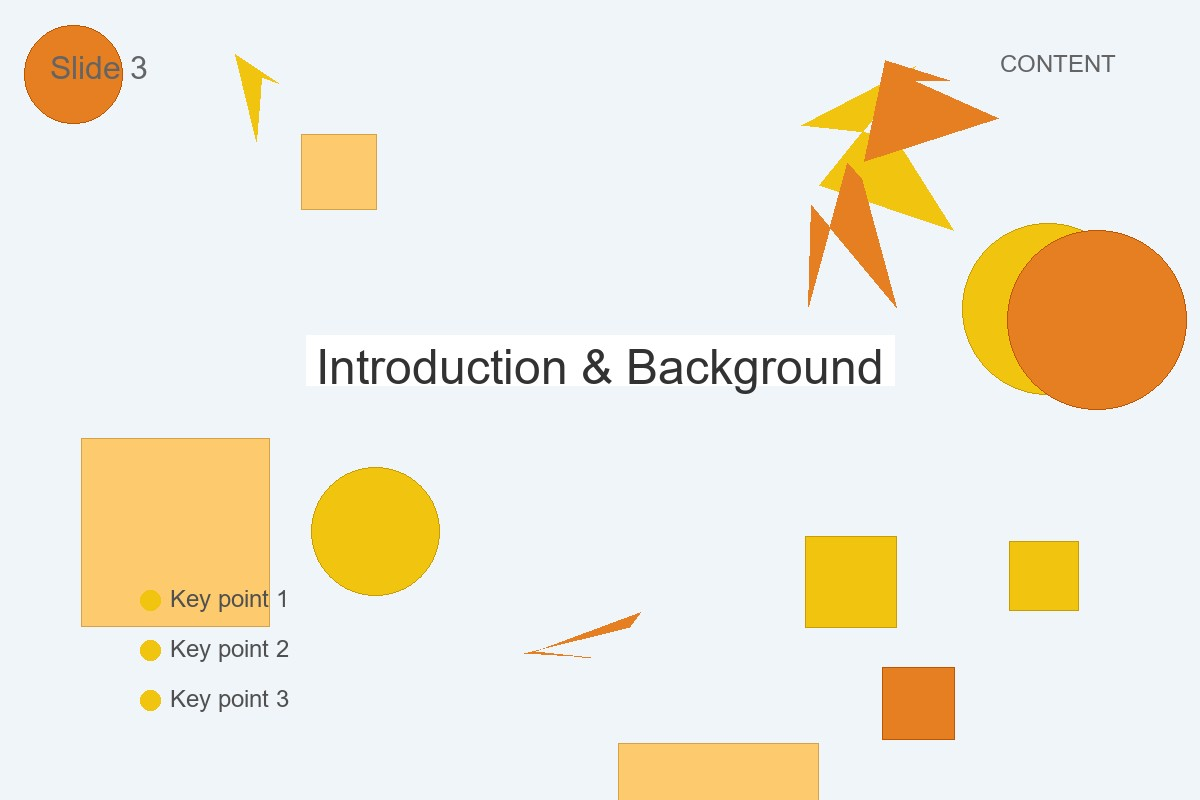

  • graphic_4473f5e39eb2.jpg


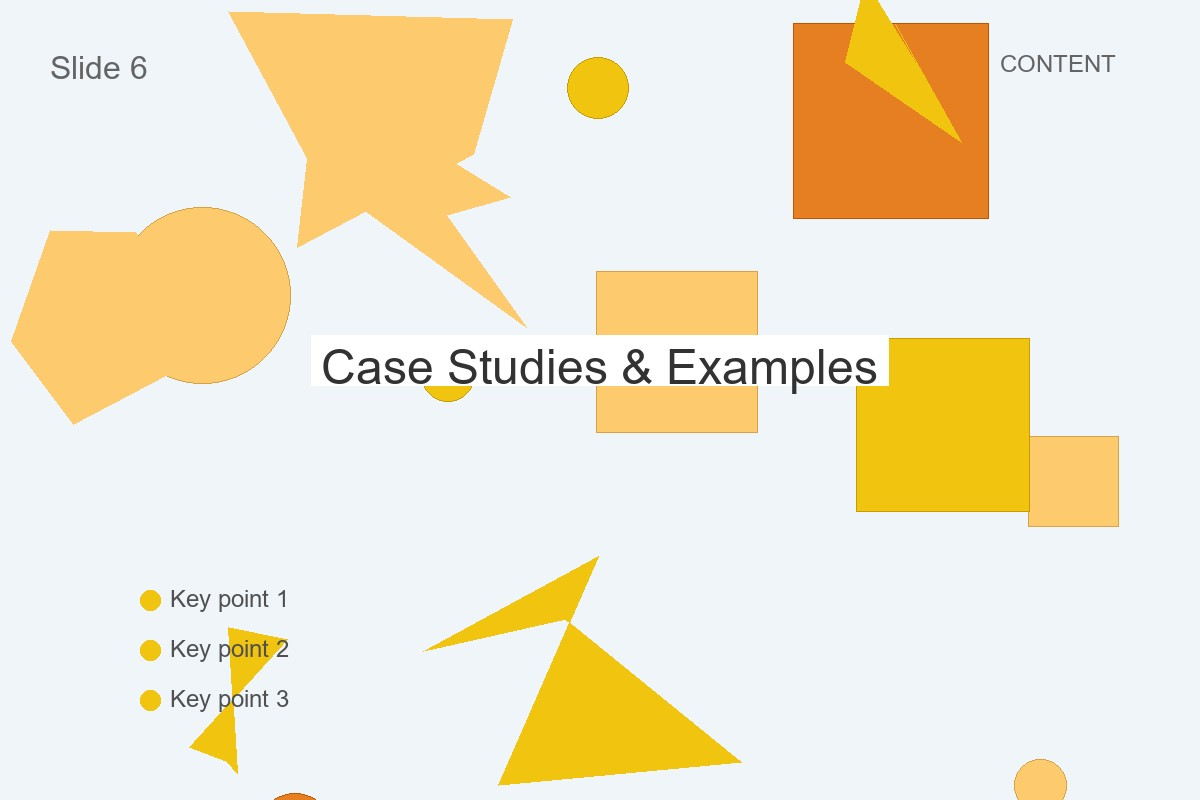

In [9]:
# Cell 3: Display some images
import glob
from IPython.display import Image as IPImage, display

print("\n📸 SAMPLE IMAGES USED:")
print("="*40)

# Show Pexels images if any
pexels_path = "presentation_images/pexels_cache"
if os.path.exists(pexels_path):
    pexels_images = glob.glob(os.path.join(pexels_path, "*.jpg"))
    if pexels_images:
        print("📸 Professional Photos from Pexels:")
        for img_path in pexels_images[:2]:
            img_name = os.path.basename(img_path)
            print(f"  • {img_name}")
            try:
                display(IPImage(filename=img_path, width=300))
            except:
                print("    (Preview not available)")

# Show generated graphics
graphics_path = "presentation_images/graphics_cache"
if os.path.exists(graphics_path):
    graphics_images = glob.glob(os.path.join(graphics_path, "*.jpg"))
    if graphics_images:
        print("\n🎨 Generated Graphics:")
        for img_path in graphics_images[:2]:
            img_name = os.path.basename(img_path)
            print(f"  • {img_name}")
            try:
                display(IPImage(filename=img_path, width=300))
            except:
                print("    (Preview not available)")